### **Power Transformer**

A power transformer is a data transformation technique used to change the shape of a numerical feature’s distribution.
Its main goal is to:
- reduce skewness
- make data more symmetric (closer to normal distribution)
- stabilize variance
- Many machine learning models work better when input data is not highly skewed.

### **Box–Cox Transformer**

The Box–Cox transformer is a mathematical method used to transform only positive numerical values.

It applies a power function controlled by a parameter (lambda) that reshapes the data distribution.
Depending on the value of lambda, the transformation may behave like:

- log transformation
- square root transformation
- linear transformation

**Its purpose is to:**
- reduce right-skewed data
- make variance more constant
- improve model learning

**Limitation:**

Box–Cox cannot be applied if the data contains:

- zero values
- negative values

### **Yeo–Johnson Transformer**

The Yeo–Johnson transformer is a modified version of Box–Cox.

**It was designed to handle real-world data, which often contains:**

- zero values

- negative values

**Yeo–Johnson applies different power formulas depending on whether the value is**:

- positive

- zero

- negative

**The goal is the same as Box–Cox:**

- reduce skewness

- normalize data

- stabilize variance

But it is more flexible and safer to use when you are unsure about the data range.

**In short**

- **Power Transformer** → general idea of reshaping data

- **Box–Cox** → works only with positive values

- **Yeo–Johnson** → works with all numeric values

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import PowerTransformer

In [ ]:
data = pd.read_csv("concrete_data.csv")

In [ ]:
data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [ ]:
data.isna().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [ ]:
data.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [ ]:
x = data.drop("Strength", axis=1)
y = data["Strength"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

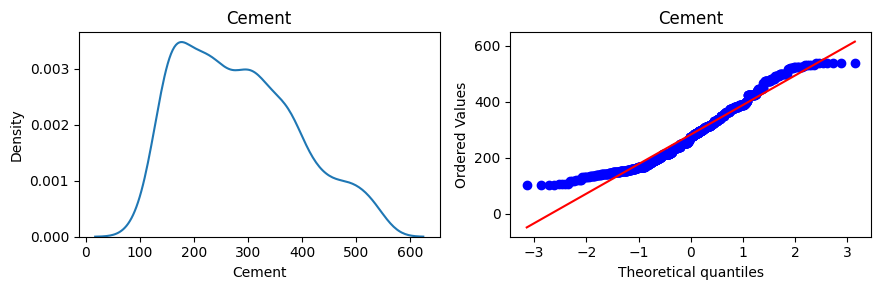

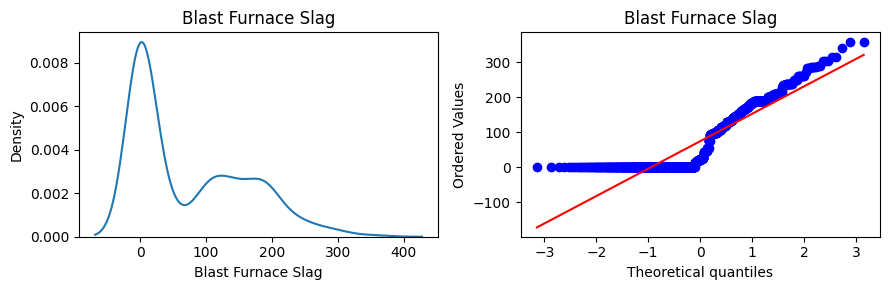

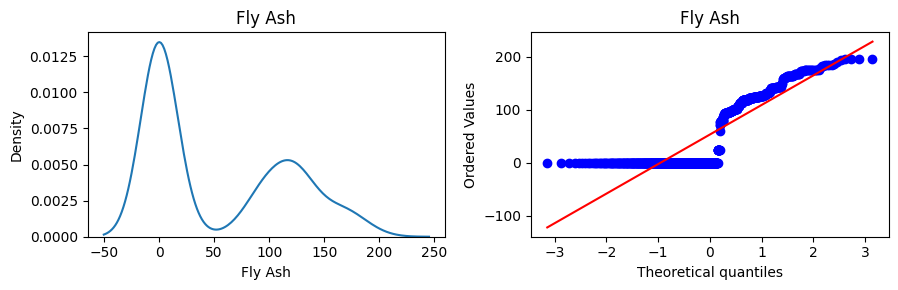

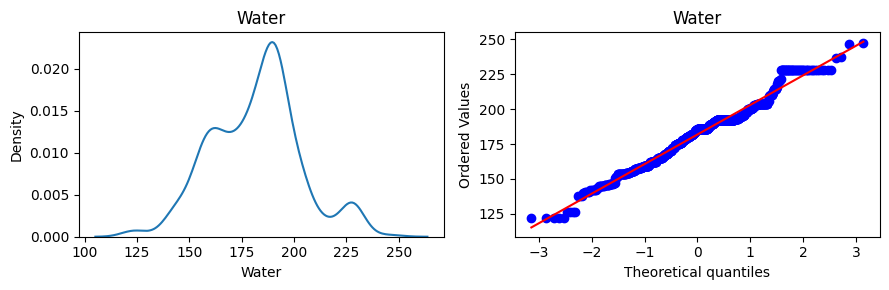

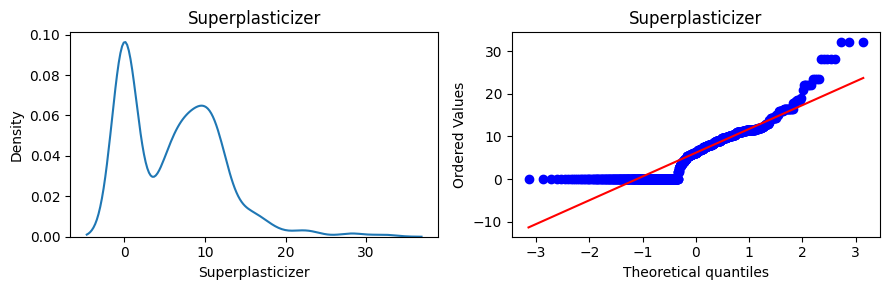

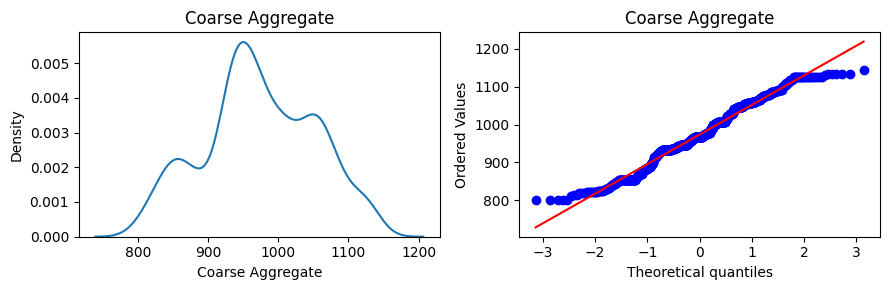

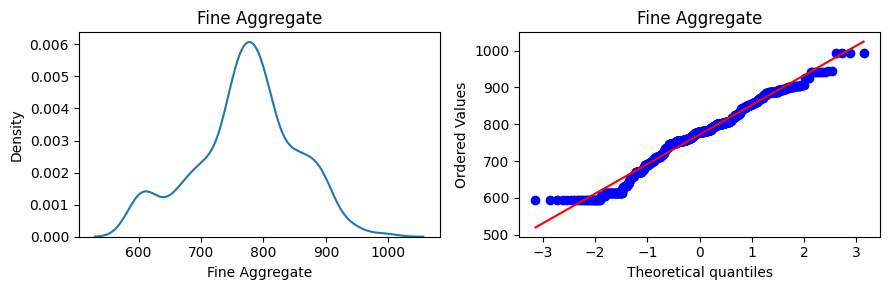

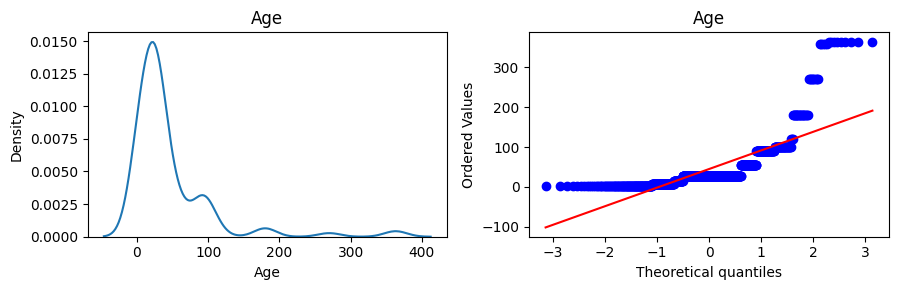

In [ ]:
# Plotting the distplots without any transformation

for col in x_train.columns:
    plt.figure(figsize=(9,3))
    plt.subplot(1,2,1)
    sns.kdeplot(x_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    stats.probplot(x_train[col], dist="norm", plot=plt)
    plt.title(col)
    plt.tight_layout()

    plt.show()

In [ ]:
# Applying linear regression without any transformer
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

acc = r2_score(y_test,y_pred)
acc

0.627553179231485

In [ ]:
# cross checking with cross_val_score

lr = LinearRegression()
np.mean(cross_val_score(lr, x, y, scoring="r2"))

np.float64(0.46099404916628606)

# Applying Box-Cox Transformation

In [ ]:
pt = PowerTransformer(method="box-cox")

x_train_transformed = pt.fit_transform(x_train+0.000001)               # Adding 0.000001 because our data contains 0 values and BOx-Cox doesn't work well on 0 values
x_test_transformed = pt.transform(x_test+0.000001)

In [ ]:
pd.DataFrame({"cols":x_train.columns,"box_cox_lambads":pt.lambdas_})              # for only understanding how lambda value is changing

,cols,box_cox_lambads
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [ ]:
# Applying linear regression on transformed data
lr = LinearRegression()
lr.fit(x_train_transformed, y_train)

y_pred = lr.predict(x_test_transformed)

acc = r2_score(y_test,y_pred)
acc

0.8047824993083206

In [ ]:
# Using cross val score
pt = PowerTransformer(method='box-cox')
x_transformed = pt.fit_transform(x+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,x_transformed,y,scoring='r2'))

np.float64(0.6658537935432477)

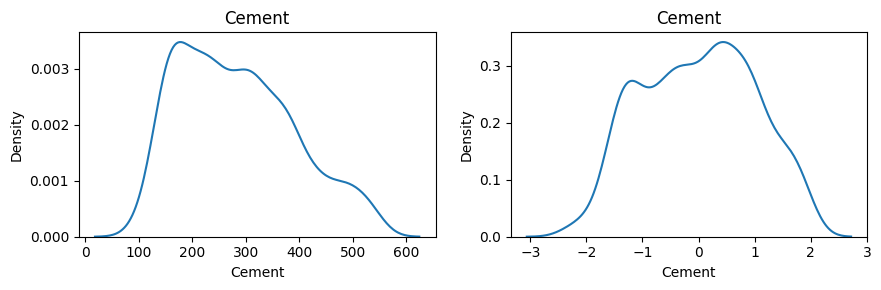

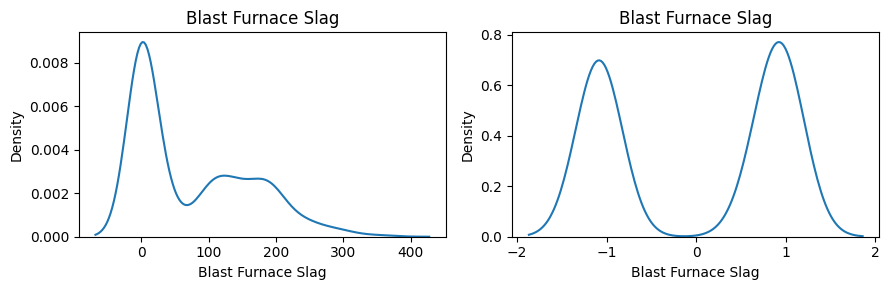

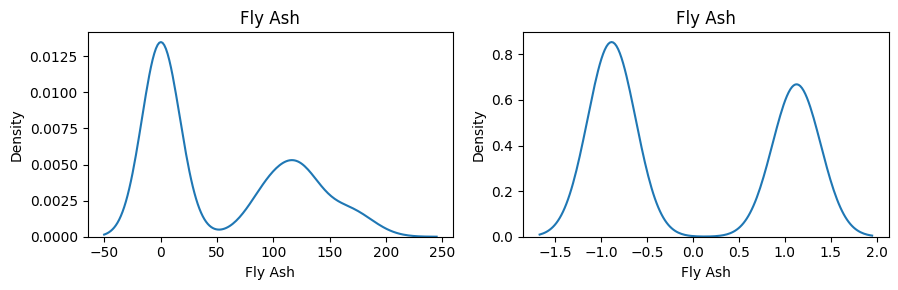

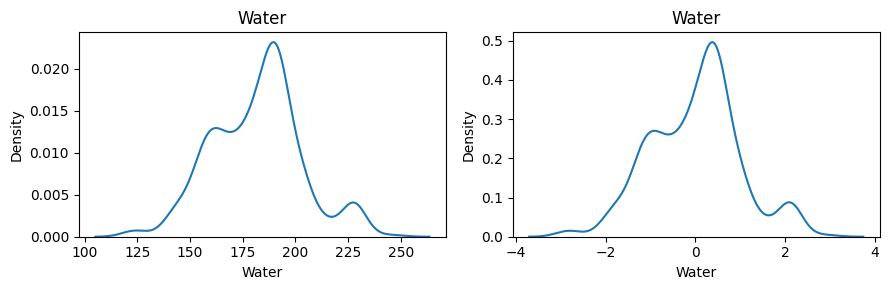

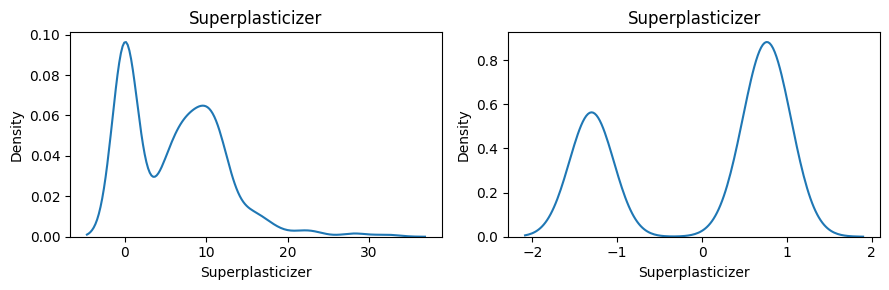

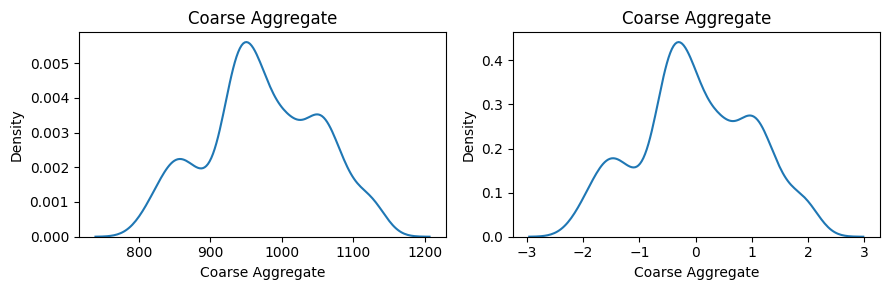

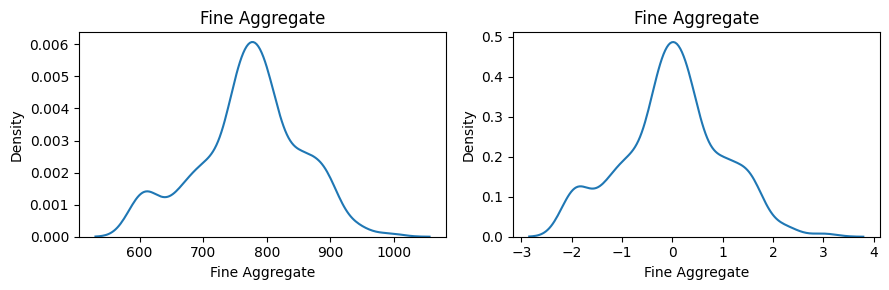

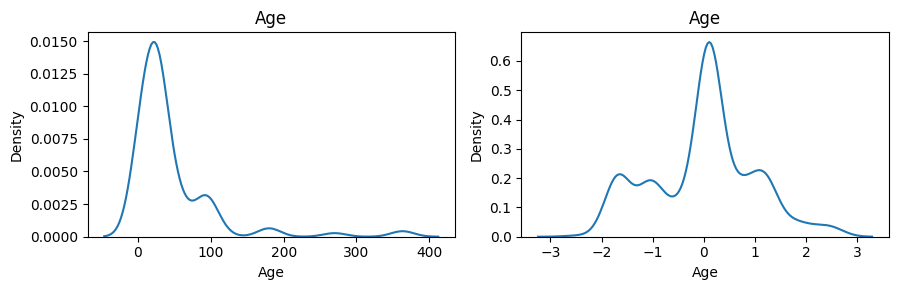

In [ ]:
# Before and after comparision for Box-Cox Plot
x_train_transformed = pd.DataFrame(x_train_transformed,columns=x_train.columns)

for col in x_train_transformed.columns:
    plt.figure(figsize=(9,3))
    plt.subplot(1,2,1)
    sns.kdeplot(x_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    sns.kdeplot(x_train_transformed[col])
    plt.title(col)

    plt.tight_layout()
    plt.show()

# Yeo Jhonsan Tranformer

In [ ]:
pty = PowerTransformer(method="yeo-johnson")

x_train_transformed_y = pty.fit_transform(x_train)
x_test_transformed_y = pty.transform(x_test)

In [ ]:
# Applying linear regression on transformed data
lr = LinearRegression()
lr.fit(x_train_transformed_y, y_train)

y_pred = lr.predict(x_test_transformed_y)

acc = r2_score(y_test,y_pred)
acc

0.8161906512004999

In [ ]:
# Using cross val score
pty = PowerTransformer(method='yeo-johnson')
x_transformed = pty.fit_transform(x+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,x_transformed,y,scoring='r2'))

np.float64(0.6834625147585041)

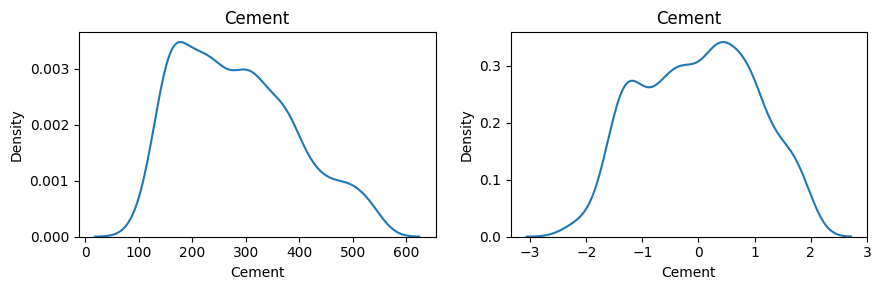

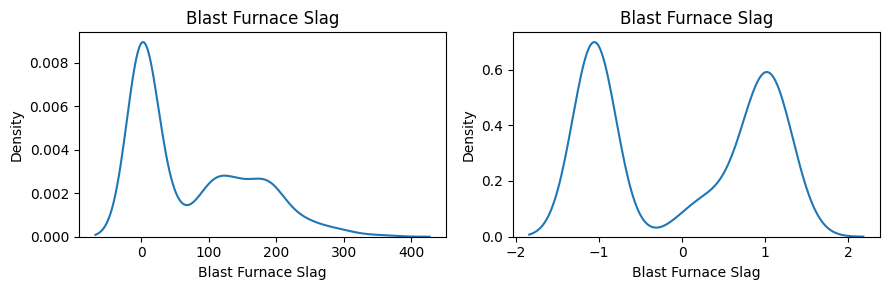

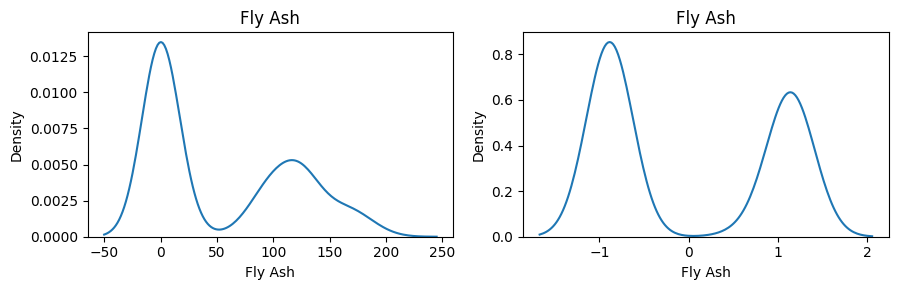

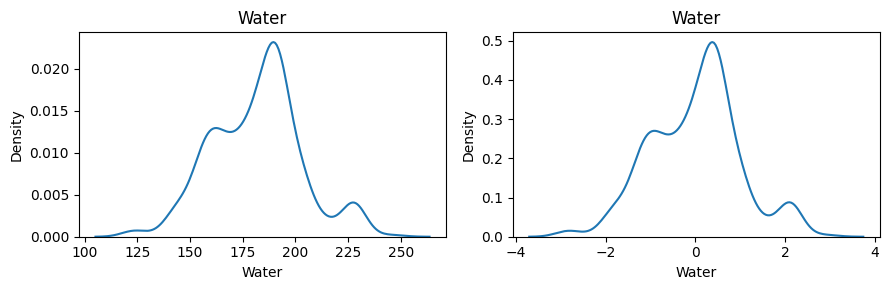

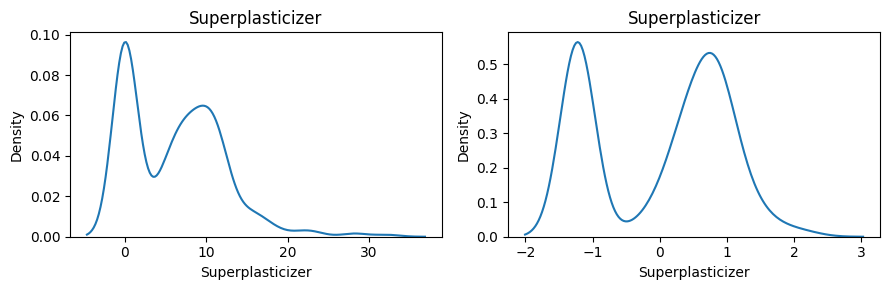

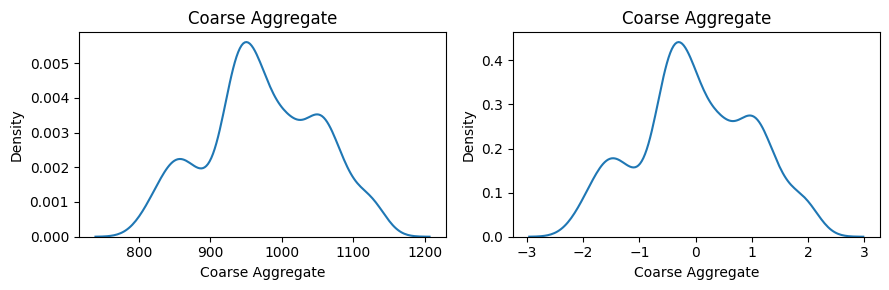

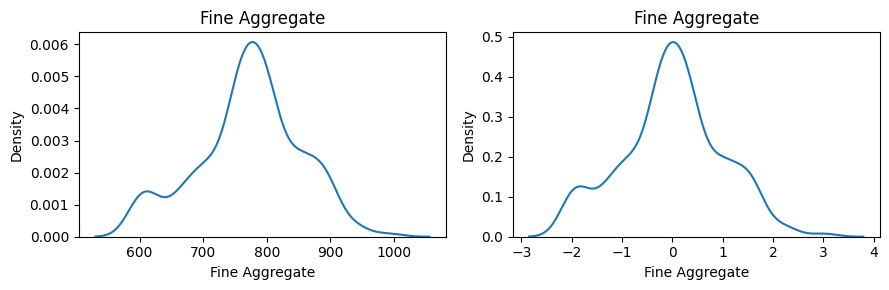

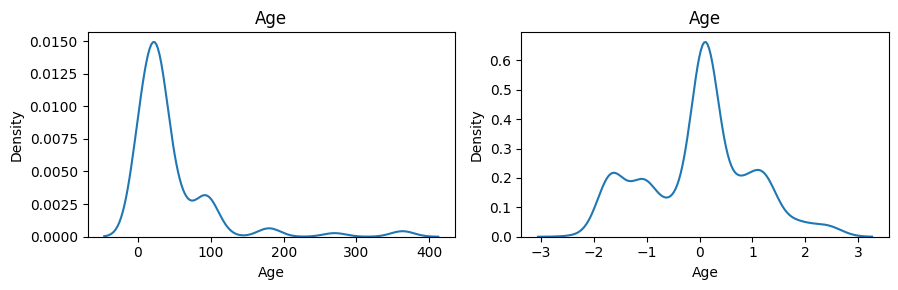

In [ ]:
# Before and after comparision for Box-Cox Plot
x_train_transformed = pd.DataFrame(x_train_transformed_y,columns=x_train.columns)

for col in x_train_transformed.columns:
    plt.figure(figsize=(9,3))
    plt.subplot(1,2,1)
    sns.kdeplot(x_train[col])
    plt.title(col)

    plt.subplot(1,2,2)
    sns.kdeplot(x_train_transformed[col])
    plt.title(col)

    plt.tight_layout()
    plt.show()